In [1]:
#%load_ext autoreload
#%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Автоматический подбор элементов дизайна на основе визуального представления

In [2]:
from tqdm import tqdm
from PIL import Image
import torch
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.gridspec import GridSpec
#
from img2vec_pytorch import Img2Vec
#
import ultralytics
from ultralytics import YOLO
#
from ultralytics.cfg import get_cfg

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.is_available()}')
    print(f'CUDA version: {torch.version.cuda}')
    print(f'count: {torch.cuda.device_count()}')
    print(f'index: {torch.cuda.current_device()}')
    print(f'name: {torch.cuda.get_device_name(0)}')
else:
    print('Nvidia GPU отсутствует или PyTorch не установлен для CUDA')

GPU: True
CUDA version: 12.6
count: 1
index: 0
name: NVIDIA GeForce RTX 4060


In [5]:
current_dir = os.getcwd()
data_dir = os.path.join(current_dir, 'data', 'ImageSearch')
print(data_dir)
print()
print('В ней находятся:')
print(os.listdir(data_dir))

E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\ImageSearch

В ней находятся:
['dataset', 'user_img']


In [6]:
db_dir = os.path.join(data_dir, 'dataset')
print(db_dir)
print()
print('В ней находятся:')
print(os.listdir(db_dir))

E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\ImageSearch\dataset

В ней находятся:
['data.csv', 'images']


In [7]:
db_images_dir = os.path.join(db_dir, 'images')
print(db_images_dir)
print()
print('В ней находятся:')
print(os.listdir(db_images_dir))

E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\ImageSearch\dataset\images

В ней находятся:
['chair1.png', 'chair2.png', 'chair3.png', 'couch1.jpg', 'couch2.png', 'couch3.png', 'cup1.jpg', 'cup2.jpg', 'cup3.png']


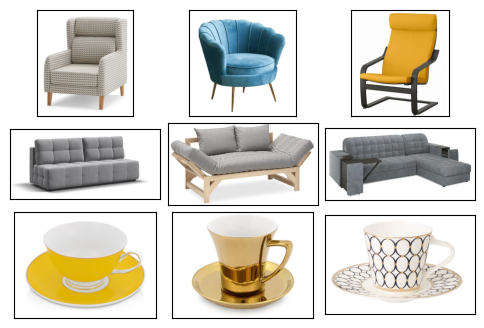

In [8]:
db_images = os.listdir(db_images_dir)

fig = plt.figure(figsize=(6, 4), dpi=100)
for i in range(9):
    ax = plt.subplot(3, 3, i+1)
    img_path = os.path.join(db_images_dir, db_images[i])
    pil_img = Image.open(img_path).convert('RGB')
    plt.imshow(pil_img)
    plt.xticks([])
    plt.yticks([])

plt.subplots_adjust(wspace=0.05, hspace=-0.05)
plt.show();

## 1. Рассчитываем эмбеддинги для набора данных

### 1.1. Пример рассчета эмбеддингов и поиск похожего изображения

In [9]:
# Инициализируем класс Img2Vec для рассчета эмбеддингов
img2vec = Img2Vec(
    model='resnet50',
    layer_output_size=2048,
    #cuda=False
    cuda=True
)

# resnet50   2048
# alexnet    4096
# vgg        4096
# densenet   1024

In [10]:
# Подготавливаем несколько изображений из набора данных
db_img1 = os.path.join(db_images_dir, 'chair1.png')
db_img2 = os.path.join(db_images_dir, 'chair2.png')
db_img3 = os.path.join(db_images_dir, 'chair3.png')
db_img4 = os.path.join(db_images_dir, 'couch1.jpg')
db_img5 = os.path.join(db_images_dir, 'couch2.png')
db_img6 = os.path.join(db_images_dir, 'couch3.png')
db_img7 = os.path.join(db_images_dir, 'cup1.jpg')
db_img8 = os.path.join(db_images_dir, 'cup2.jpg')
#db_img9 = os.path.join(db_images_dir, 'cup3.png')

# Подготавливаем одно пользовательское изображение, для которого
# будет осуществлён поиск наиболее похожих из набора данных
test_img = os.path.join(db_images_dir, 'cup3.png')
#test_img = os.path.join(db_images_dir, 'chair3.png')
#test_img = os.path.join(db_images_dir, 'couch3.png')

In [11]:
# Открываем каждое изображение, конвертируем в RGB и помещаем в список
db_imgs = [
    Image.open(db_img1).convert('RGB'),
    Image.open(db_img2).convert('RGB'),
    Image.open(db_img3).convert('RGB'),
    Image.open(db_img4).convert('RGB'),
    Image.open(db_img5).convert('RGB'),
    Image.open(db_img6).convert('RGB'),
    Image.open(db_img7).convert('RGB'),
    Image.open(db_img8).convert('RGB'),
    #Image.open(db_img9).convert('RGB'),
]

# Открываем пользовательское изображение, конвертируем в RGB и помещаем в список
test_img = [
    Image.open(test_img).convert('RGB')
]

In [12]:
# Рассчитываем эмбеддинги для изображений из набора данных
db_embeddings = img2vec.get_vec(db_imgs)
#
print(db_embeddings.shape)
print()
print(db_embeddings)

(8, 2048)

[[          0           0       1.111 ...    0.034841           0           0]
 [          0   0.0021969      2.7289 ...           0   0.0045184    0.014889]
 [   0.044465           0      4.4563 ...    0.042121           0           0]
 ...
 [          0           0     0.49544 ...           0           0           0]
 [  0.0036884           0           0 ...           0           0           0]
 [          0           0    0.023779 ...           0           0           0]]


In [13]:
# Рассчитываем эмбеддинг для пользовательского изображения
test_embeddings = img2vec.get_vec(test_img)
#
print(test_embeddings.shape)
print()
print(test_embeddings)

(1, 2048)

[[          0           0     0.12532 ...           0    0.057769           0]]


In [14]:
# Рассчитываем косинусное расстояние между пользовательским эмбеддингом
# и каждым из набора данных
similarities = cosine_similarity(test_embeddings, db_embeddings)

#
print(similarities.shape)
print()
print(similarities)

# Значение косинусного расстояния будет варьироваться от -1 до 1:
#  1 означает полное совпадение
# -1 полное несовпадение

(1, 8)

[[    0.14065      0.1123     0.14137     0.11645    0.092947       0.106     0.69126     0.61917]]


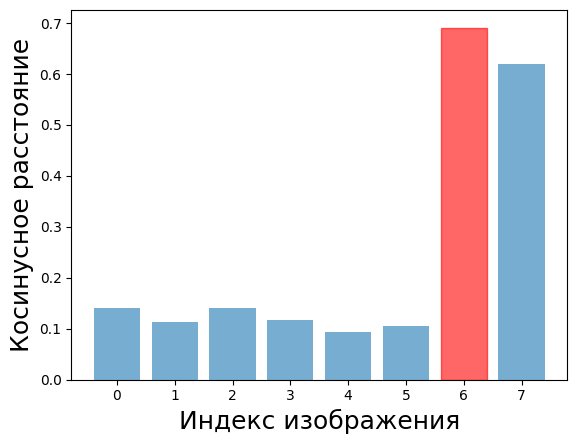

In [15]:
# Отображаем косинусные расстояния с помощью столбчатой диаграммы

# Создаём столбчатую диаграмму
barlist = plt.bar(
    [str(i) for i in range(len(similarities[0]))],  # значения вдоль оси X
    similarities[0],                                # значения вдоль оси Y
    align='center',
    alpha=0.6
)

# Выделяем красным цветом наибольший столбик
barlist[np.argmax(similarities[0])].set_color('red')

plt.ylabel('Косинусное расстояние', fontsize=18)
plt.xlabel('Индекс изображения', fontsize=18)
plt.show()

In [16]:
# Находим индексы наиболее похожих изображений в порядке убывания
number = 8
idxs = np.argsort(similarities[0])[::-1][:number]

print('Индексы наиболее похожих изображений в порядке убывания:')
print(idxs)

Индексы наиболее похожих изображений в порядке убывания:
[6 7 2 0 3 1 5 4]


In [17]:
# Извлекаем из набора данных изображения
# в соответствие с индексами наиболее похожих изображений
found_imgs = [db_imgs[i] for i in idxs]

# Извлекаем рассчитанные косинусные расстояния
# в соответствие с индексами наиболее похожих изображений
similarities_found = [similarities[0][i] for i in idxs]
print(similarities_found)

[np.float32(0.6912607), np.float32(0.6191699), np.float32(0.14137106), np.float32(0.14064634), np.float32(0.11644777), np.float32(0.11229944), np.float32(0.105995774), np.float32(0.092947155)]


In [18]:
# Создаём функцию, которая строит график
# для визуализации результатов поиска
def search_results(test_img, found_imgs, similarities_found, save_path=os.path.join(os.getcwd(), 'search_results.jpg'),
                   test_title='Пользовательское \n изображение', show=True):   
    # Считаем необходимое количество строк
    # для визуализации найденных изображений
    rows = len(found_imgs)

    # Создаём график
    # Подготавливаем график для визуализации изображений
    fig = plt.figure(figsize=(8, 8), dpi=100)
    gs = fig.add_gridspec(rows, 2)  # строки и 2 столбца

    # Показываем похожие изображения
    # Создаём в правом столбце внутренние графики
    ax = [fig.add_subplot(gs[i, 1]) for i in range(rows)]

    # Визуализируем в правом столбце изображения,
    # которые наиболее похожи на пользовательское,
    # в порядке убывания схожести
    _ = [ax[i].imshow(found_imgs[i]) for i in range(len(ax))]

    # Подписываем в правом столбце каждое изображение,
    # указывая в качестве названия косинусное расстояние
    # между пользовательским эмбеддингом и текущим изображением
    _ = [ax[i].set_title('cos: ' + str(similarities_found[i]), color='0.7') for i in range(len(ax))]

    # Отключаем отображения осей
    _ = [ax[i].set_axis_off() for i in range(len(ax))]

    # Показываем пользовательское изображение
    # Создаём в левом столбце 1 внутренний график, занимая все строки
    ax_big = fig.add_subplot(gs[:, 0])

    # Визуализируем в нём пользовательское изображение
    ax_big.imshow(test_img)

    # Даём название данному внутреннему графику и отключаем отображение осей
    ax_big.set_title(test_title, color='0.6', fontsize=10)
    ax_big.set_axis_off()

    # Даём название всему графику
    fig.suptitle('Найденные наиболее схожие изображения', color='0.4', fontsize=12)
    
    # Настраиваем отступы между внутренними графиками
    plt.tight_layout(h_pad=0.5)
    
    # Сохраняем график
    #plt.savefig(save_path, dpi=300)
    
    # Показываем график или отключаем показ
    if show:
        plt.show()
        plt.close()
    else:
        plt.close()

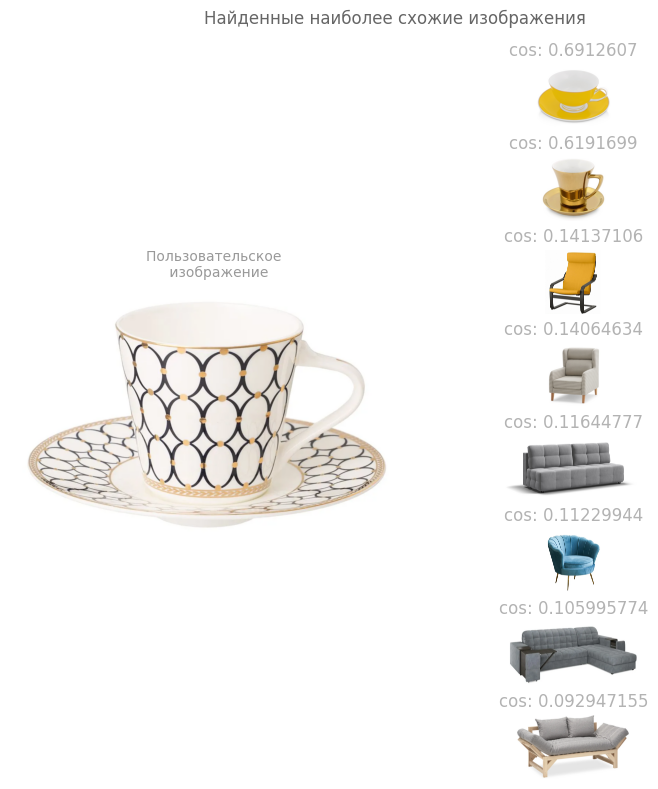

In [19]:
# Вызываем функцию для визуализации результатов поиска
search_results(test_img[0], found_imgs, similarities_found)

### 1.2. Рассчитываем эмбеддинги для всего набора данных

In [20]:
# Инициализируем класс Img2Vec для рассчета эмбеддингов
img2vec = Img2Vec(
    model='resnet50',
    layer_output_size=2048,
    #cuda=False
    cuda=True
)

# resnet50   2048
# alexnet    4096
# vgg        4096
# densenet   1024

In [21]:
# Читаем 'csv' файл с базой данных изображений
# и помещаем его в Pandas DataFrame
path_to_data = os.path.join(db_dir, 'data.csv')
df = pd.read_csv(path_to_data, sep=';')
#
df.head(10)

,image_filename,description,link_to_market,price
0,cup1.jpg,Чайная пара: чашка на 200 мл с блюдцем,https://link_to_market,305
1,cup2.jpg,Золотая чайная пара: чашка на 180 мл с блюдцем,https://link_to_market,195
2,cup3.png,Чайная пара из фарфора Lefard Breeze: чашка 25...,https://link_to_market,1350
3,chair1.png,Кресло для отдыха SCANDICA Дженифер,https://link_to_market,15000
4,chair2.png,Кресло серо-голубое Ракушка,https://link_to_market,55000
5,chair3.png,Кресло Поэнг. Каркас черно-коричневый с желтой...,https://link_to_market,16500
6,couch1.jpg,Диван Dandy MINI SE велюр Monolit сталь,https://link_to_market,29900
7,couch2.png,Диван кушетка Амбер-2 серый,https://link_to_market,12500
8,couch3.png,"Угловой диван Аккорд, аккордеон на независимом...",https://link_to_market,85900


In [22]:
# Извлекаем столбец с названиями изображений и конвертируем его в список
imgs_file_names = df['image_filename'].to_list()
#
print(imgs_file_names)

['cup1.jpg', 'cup2.jpg', 'cup3.png', 'chair1.png', 'chair2.png', 'chair3.png', 'couch1.jpg', 'couch2.png', 'couch3.png']


In [23]:
# Подготавливаем пути к изображениям
imgs_file_paths = [os.path.join(db_images_dir, name) for name in imgs_file_names]
#
print(len(imgs_file_paths))

9


In [24]:
# Открываем каждое изображение, конвертируем в RGB и помещаем в список
imgs_opened = [Image.open(name).convert('RGB') for name in imgs_file_paths]
#
print(len(imgs_opened))

9


In [25]:
# Рассчитываем эмбеддинги для всех изображений из набора данных
imgs_embeddings = img2vec.get_vec(imgs_opened)
#
print(imgs_embeddings.shape)
print()
print(imgs_embeddings)

(9, 2048)

[[  0.0036884           0           0 ...           0           0           0]
 [          0           0    0.023779 ...           0           0           0]
 [          0           0     0.12558 ...           0    0.057815           0]
 ...
 [          0           0     0.93594 ...     0.04048           0           0]
 [          0    0.025612      2.3375 ...           0           0           0]
 [          0           0     0.49544 ...           0           0           0]]


In [26]:
# Создаём новый Pandas DataFrame с эмбеддингами,
# где каждый столбик - это одно значение из вектора
df_imgs_embeddings = pd.DataFrame(imgs_embeddings)
#
df_imgs_embeddings.head(10)

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0.003688,0.000000,0.000000,0.0,0.000000,0.000000,0.003391,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.022452,0.0,0.0,0.017915,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.023779,0.0,0.020152,0.016166,0.238530,0.022107,0.014134,0.018924,...,0.000000,0.951697,0.000000,0.0,0.0,0.282643,0.012555,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.125576,0.0,0.075836,0.028497,0.559062,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.006523,0.000000,0.000000,0.057815,0.000000
3,0.000000,0.000000,1.111048,0.0,0.000000,0.000000,0.000000,0.015568,0.000000,0.000000,...,0.000000,0.000000,0.390483,0.0,0.0,0.000000,0.000000,0.034841,0.000000,0.000000
4,0.000000,0.002197,2.728914,0.0,0.001734,0.000000,0.212846,0.010012,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.004518,0.014889
5,0.044465,0.000000,4.456269,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.074004,0.0,0.0,0.000000,0.000000,0.042121,0.000000,0.000000
6,0.000000,0.000000,0.935935,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.135598,0.0,0.0,0.000000,0.000000,0.040480,0.000000,0.000000
7,0.000000,0.025612,2.337546,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.020190,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.495437,0.0,0.000000,0.003443,0.000000,0.000000,0.000000,0.000000,...,0.006389,0.000000,0.016678,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


In [27]:
# Объединяем два Pandas DataFrame в один
df_updated = pd.concat([df, df_imgs_embeddings], axis=1)
#
df_updated.head(3)

,image_filename,description,link_to_market,price,0,1,2,3,4,5,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,cup1.jpg,Чайная пара: чашка на 200 мл с блюдцем,https://link_to_market,305,0.003688,0.0,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.022452,0.0,0.0,0.017915,0.000000,0.0,0.000000,0.0
1,cup2.jpg,Золотая чайная пара: чашка на 180 мл с блюдцем,https://link_to_market,195,0.000000,0.0,0.023779,0.0,0.020152,0.016166,...,0.0,0.951697,0.000000,0.0,0.0,0.282643,0.012555,0.0,0.000000,0.0
2,cup3.png,Чайная пара из фарфора Lefard Breeze: чашка 25...,https://link_to_market,1350,0.000000,0.0,0.125576,0.0,0.075836,0.028497,...,0.0,0.000000,0.000000,0.0,0.0,0.006523,0.000000,0.0,0.057815,0.0


In [28]:
# Сохраняем обновлённый Pandas DataFrame в 'csv' файл
path_to_data_updated = os.path.join(db_dir, 'data_updated.csv')
#df_updated.to_csv(path_to_data_updated, sep=';', index=False, header=True, encoding='utf-8')